# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [15]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv')
usage = pd.read_csv('usage.csv')

In [17]:
# mostrar las primeras 5 filas de plans
print("plans")
plans.head()

plans


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [18]:
# mostrar las primeras 5 filas de users
print("users")
users.head()

users


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [19]:
# mostrar las primeras 5 filas de usage
print("usage")
usage.head()

usage


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [20]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [21]:
# inspección de plans con .info()
print("plans info")
plans.info()

plans info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [22]:
# inspección de users con .info()
print("users info")
users.info()

users info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [23]:
# inspección de usage con .info()
print("usage info")
usage.info()

usage info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [24]:
# cantidad de nulos para users
print("Cantidad de valores nulos en :")
print(users.isna().sum())
print("\nProporción de valores nulos en users:")
print(users.isna().mean())

Cantidad de valores nulos en :
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos en users:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [25]:
# cantidad de nulos para usage
print("Cantidad de valores nulos en usage:")
print(usage.isna().sum())
print("\nProporción de Valores nulos en usage")
print(usage.isna().mean())

Cantidad de valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de Valores nulos en usage
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.
💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 ---
**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- city (11.7%), churn_date (88.3%), date (0.1%), duration (55%), length (45%).
- 
- Indica qué harías: ¿imputar, eliminar, ignorar?
- Recomendaciones no borrar ninguna columna ya que todas aportan informacion
- Imputar valores: city por desconocido y quiza date si afecta en el analisis entonces investigar
- churn_date: mantener nulos porque significan cliente activo.
- date: ignorar o imputar porque es muy bajo.
- Mantener nulos de duration y length por que transmiten la logica del negocio (llamdas vs mensajes)

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [26]:
# explorar columnas numéricas de users
print(users[['user_id', 'age']].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


Haz doble clic en este bloque y escribe qué ves.
- La columna `user_id` los valores van consecutivos de 10mil hasta 13mil, los user_id son enteros consecutivos y únicos, no presentan valores inválidos.
- La columna `age` minimo =-999 (se ve claro un sentinel), maximo = 79,l a columna age tiene un valor inválido (-999) que funciona como sentinel. El resto de edades están en un rango razonable (15–79)

In [27]:
# explorar columnas numéricas de usage
print(usage[['id','user_id','duration','length']].describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


  Haz doble clic en este bloque y escribe qué ves.
- Las columnas `id` y `user_id` id va de 1 a 40000, user_id coincide con el rango de users (10000–13999).
- Las columnas los identificadores son consistentes y están dentro del rango esperado.

In [28]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users['city'].unique())
print(users['plan'].unique())

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']


- La columna `city` contiene nombres de ciudades válidas como Medellín, CDMX, Bogotá, GDL, MTY, Cali, pero también aparecen valores inválidos como "?" y algunos NaN. Esto indica que hay registros con ciudad desconocida o mal capturada, lo cual requiere limpieza o imputación.
- La columna `plan` solo tiene dos valores posibles (Basico y Premium), lo cual es consistente y correcto. No se detectan valores inválidos ni sentinels.

In [29]:
# explorar columna categórica de usage
print(usage['type'].unique())

['call' 'text']


- La columna `type`  contiene únicamente dos valores (call y text), lo cual es consistente con el diseño del dataset. No se detectan valores inválidos ni sentinels, por lo que no requiere limpieza adicional.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- users.age: valor sentinel -999, users.city: valor inválido "?" y algunos NaN. El resto (plan, type) son consistentes y correctos.
- ¿Qué acción tomarías?
- Remplazar -999 por NaN y luego decidir imputacion o eliminacion, city imputar "?" y NaN con desconocido plan y type se pueden quedar asi ademas de que en duration y legth mantener nulos ya que reflejan la logica.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [30]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [31]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [32]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date:")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años en reg_date:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


haz doble clic en este bloque y escribe qué ves.
En `reg_date`,  aparecen principalmente años 2022, 2023 y 2024, lo cual es correcto porque son registros recientes. Sin embargo, también se detectan 40 registros con año 2026, que está fuera del rango permitido (los datos solo llegan hasta 2024). Estos son fechas inválidas y deben corregirse o eliminarse.

In [33]:
# Revisar los años presentes en `date` de usage
print("\nAños en usage.date:")
print(usage['date'].dt.year.value_counts().sort_index())


Años en usage.date:
2024.0    39950
Name: date, dtype: int64


haz doble clic en este bloque y escribe qué ves.  
En `date`,  todos los registros corresponden al año 2024, lo cual es consistente con el diseño del dataset. No se detectan fechas fuera de rango.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Si el 2026 con datos cuando se supone que no deberian salir ya que el rango es hasta el 2024
- ¿Qué harías con ellas?
- Para reg_date con año 2026: marcar esos registros como inválidos y decidir si se corrigen (si fue error de captura) o se eliminan del análisis.
- Para date: mantener sin cambios, ya que los valores son correctos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [34]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999,'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [35]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [36]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users["reg_date"].dt.year.value_counts().sort_index())


2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [37]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [38]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
En duration:
Para registros con type = call, el porcentaje de nulos es 0% (no hay valores faltantes).Para registros con type = text, el porcentaje de nulos es prácticamente 100%.
Esto confirma que los nulos dependen directamente del tipo de uso: los mensajes no tienen duración.

En length:
Para registros con type = text, el porcentaje de nulos es 0% (todos tienen longitud).Para registros con type = call, el porcentaje de nulos es prácticamente 100%.
Esto confirma que los nulos dependen directamente del tipo de uso: las llamadas no tienen longitud de mensaje.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [42]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum", "is_call": "sum", "duration": "sum"}).reset_index()
# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [44]:
# Renombrar columnas

usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [45]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [46]:
# Resumen estadístico de las columnas numéricas
print(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [47]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

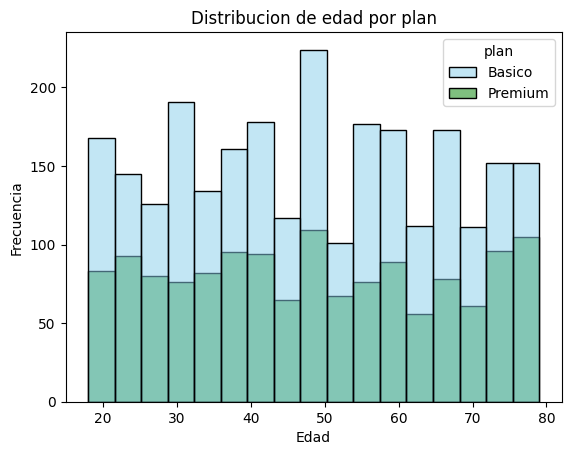

In [48]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde= False)
plt.title('Distribucion de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: Se observa un rango amplio, pero con concentración en adultos de 30 a 70 años, el plan Premium tiende a estar más presente en edades medias (40–60) y el plan Básico aparece más disperso, incluyendo jóvenes y mayores.
- Distribución sesgada a la derecha(cola hacia edades mas altas)

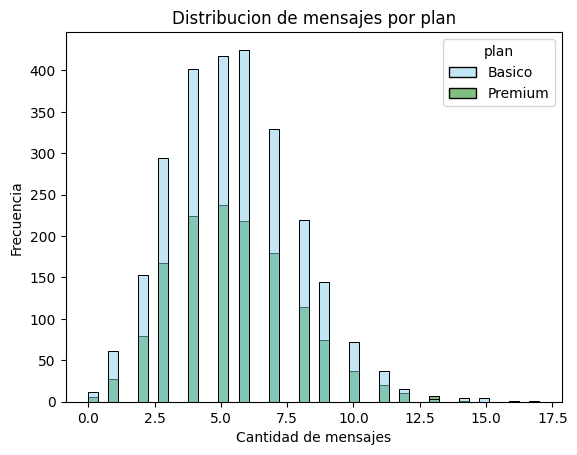

In [49]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde= False)
plt.title('Distribucion de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: La mayoría de usuarios envía pocos mensajes, pero hay algunos con volúmenes muy altos, el plan basico concentra más usuarios con altos volúmenes de mensajes y el plan premium se concentra en valores bajos.
- Distribución: sesgada a la derecha (cola hacia usuarios con muchísimos mensajes).

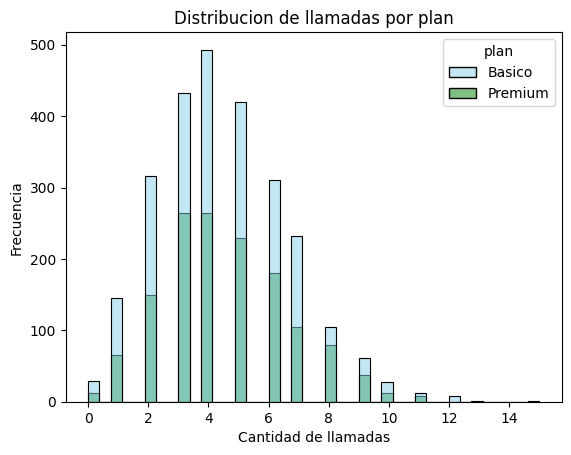

In [50]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde= False)
plt.title('Distribucion de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: La mayoría de usuarios realiza pocas llamadas, el plan basico muestra más usuarios con mayor número de llamadas y el plan premium tiene más usuarios con pocas o ninguna llamada.
- Distribución: sesgada a la derecha (cola hacia usuarios con muchas llamadas).

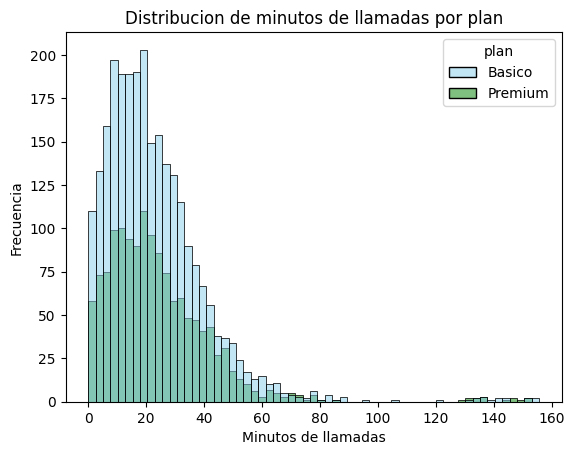

In [51]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde= False)
plt.title('Distribucion de minutos de llamadas por plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: La mayoría de usuarios acumula varios minutos de llamadas, el plan basico concentra más usuarios con altos minutos de uso y el plan premium se concentra en valores bajos.
- Distribución: sesgada a la derecha (cola hacia usuarios que hablan muchísimo).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.
**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>
- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.
**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

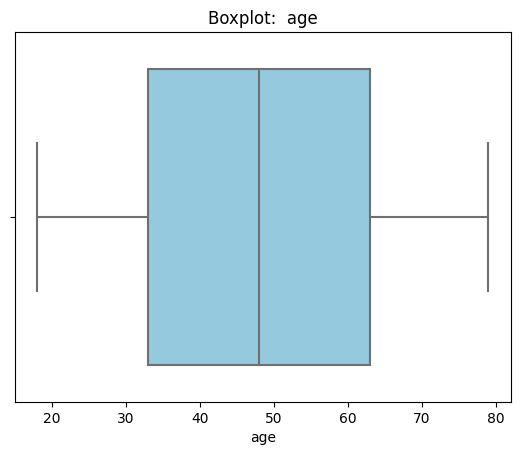

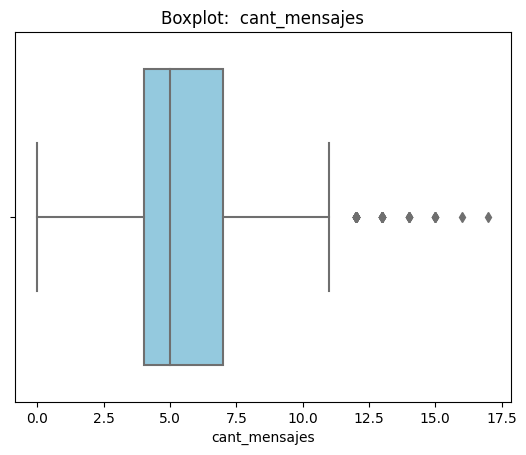

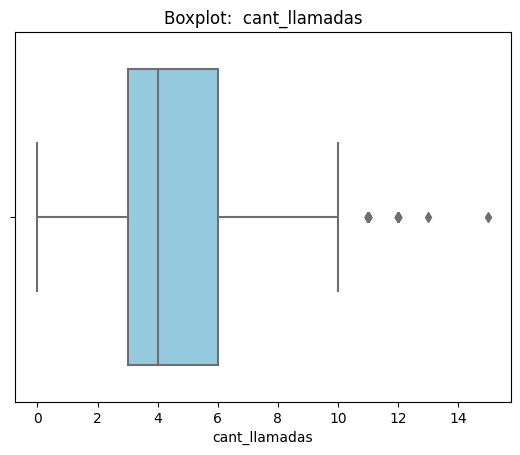

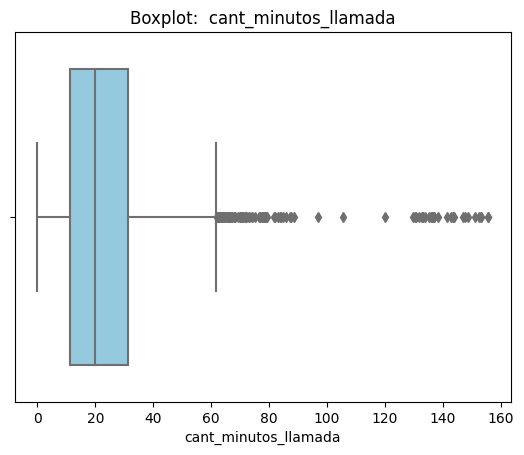

In [52]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, palette=['skyblue'])
    plt.title(f'Boxplot:  {col}')
    plt.show()

💡Insights: 
- Age: ...(presenta o no outliers) Se observa un outlier extremo en -999, que corresponde al sentinel que ya identificamos, este valor no es real y debe corregirse (ya lo reemplazamos con la mediana) y sí hay outlier, pero es un error de captura, no un comportamiento real.
- cant_mensajes: La mayoría de usuarios envía entre 3 y 8 mensajes se detectan outliers con más de 12–17 mensajes estos valores reflejan usuarios muy activos, no errores pero es mejor mantener los outliers porque representan comportamiento real.
- cant_llamadas:La mayoría de usuarios realiza entre 3 y 7 llamadas se observan outliers con más de 11–15 llamadas igual que en mensajes, son usuarios con actividad alta es mejor mantener los outliers, ya que son casos extremos válidos.
- cant_minutos_llamada:La mayoría acumula entre 10 y 35 minutos se detectan outliers con más de 60–160 minutos estos valores corresponden a usuarios que hablan mucho, no a errores y es mejor mantener los outliers porque reflejan uso intensivo.

In [53]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col}: límite inferior={limite_inferior}, límite superior={limite_superior}, max={user_profile[col].max()}")




cant_mensajes: límite inferior=-0.5, límite superior=11.5, max=17.0
cant_llamadas: límite inferior=-1.5, límite superior=10.5, max=15.0
cant_minutos_llamada: límite inferior=-19.322500000000005, límite superior=61.8575, max=155.69


In [54]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Límite superior ≈ 11.5, pero el máximo observado es 17 esto significa que sí hay outliers (usuarios que envían más mensajes de lo esperado).
Decisión: mantenerlos, porque reflejan usuarios muy activos y no errores de captura.

- cant_llamadas: mantener o no outliers, porqué? Límite superior ≈ 10.5, pero el máximo observado es 15 hay outliers de usuarios que hacen muchas llamadas.
Decisión: mantenerlos, ya que representan comportamiento real de heavy users.

- cant_minutos_llamada: mantener o no outliers, porqué? Límite superior ≈ 61.8, pero el máximo observado es 155.7 existen outliers de usuarios que acumulan muchísimos minutos de llamadas.
Decisión: mantenerlos, porque son casos extremos válidos de uso intensivo, no errores.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [56]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'
# Crear la nueva columna
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [57]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [58]:

# Crear columna grupo_edad
def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)


In [59]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

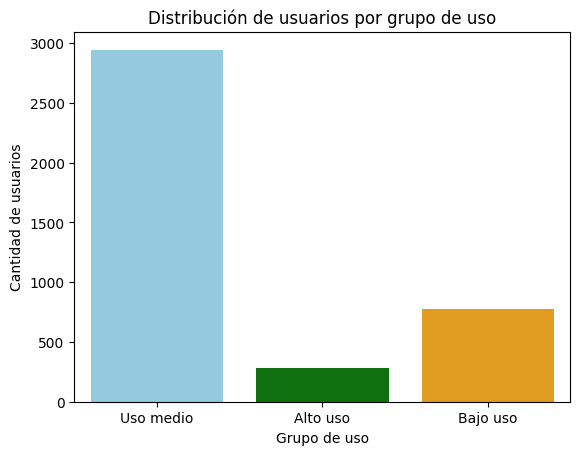

In [60]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue','green','orange'])
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

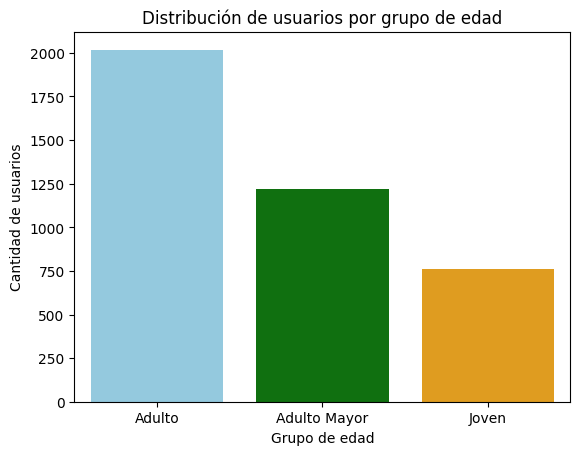

In [61]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue','green','orange'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- Se detectó un valor inválido en la columna age (-999), que representaba un error de captura este outlier afectaba el cálculo de mínimos y promedios de edad
- representaba menos del 0.1% de las filas, pero era crítico corregirlo para no distorsionar los resultados.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- Bajo uso: usuarios con menos de 5 llamadas y mensajes, uso medio: usuarios con menos de 10 llamadas y mensajes con alto uso: usuarios con mayor actividad en llamadas y mensajes y Por edad: Jóvenes (<30 años),
- Adultos (30–59 años) y Adultos mayores (60+ años).
- Al cruzar ambos segmentos: Jóvenes tienden a estar en Uso medio, Adultos concentran la mayor proporción de Alto uso Adultos mayores aparecen más en Bajo uso, aunque algunos destacan en Alto uso.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- Los Adultos en Alto uso son el segmento más atractivo: Representan clientes con alta actividad en llamadas y mensajes son más propensos a necesitar planes Premium o paquetes adicionales los Jóvenes en Uso medio también son estratégicos: Pueden migrar a planes más altos si se les ofrece beneficios digitales atractivos.
- 
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- Se identificaron usuarios con volúmenes muy altos de mensajes (>17), llamadas (>15) y minutos de llamadas (>150) estos casos no son errores, sino heavy users que representan un nicho de clientes con necesidades intensivas de comunicación. Implican que ConnectaTel debe considerar planes especiales para usuarios de alto consumo.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
- Optimizar planes Premium: reforzar beneficios para adultos de alto uso, que son el segmento más rentable crear planes híbridos para jóvenes: incluir más datos móviles y beneficios digitales para incentivar migración a planes - superiores. Ofrecer paquetes de uso intensivo: diseñar planes específicos para heavy users con llamadas y mensajes ilimitados.
- Campañas de retención: enfocar promociones en los segmentos de alto uso para evitar churn y consolidar fidelidad.

✍️ **Escribe aquí tu análisis ejecutivo:**
Problemas detectados en los datos
Se encontró un valor inválido en la columna age (-999), que representaba un error de captura.

Aunque fue menos del 0.1% de las filas, distorsionaba los cálculos de mínimos y promedios de edad.

Se corrigió reemplazándolo con la mediana para mantener consistencia en el análisis.

🔍 Segmentos por Edad
Jóvenes (<30 años): menor proporción, con actividad moderada en mensajes y llamadas.

Adultos (30–59 años): el grupo más numeroso, con mayor presencia en Uso medio y Alto uso.

Adultos mayores (60+ años): menor participación, predominan en Bajo uso, aunque algunos destacan en Alto uso.

📊 Segmentos por Nivel de Uso
Bajo uso: usuarios con menos de 5 llamadas y mensajes, baja actividad.

Uso medio: usuarios con menos de 10 llamadas y mensajes, representan la mayoría.

Alto uso: usuarios con actividad elevada en llamadas y mensajes, más frecuentes en planes Premium.

➡️ Esto sugiere que los Adultos en Alto uso son el segmento más valioso para ConnectaTel, mientras que los Jóvenes en Uso medio representan una oportunidad de crecimiento si se les ofrecen beneficios atractivos.

💡 Recomendaciones
Optimizar planes Premium para adultos de alto uso, reforzando beneficios y fidelización.

Diseñar planes digitales para jóvenes, con más datos móviles y servicios complementarios para incentivar migración a planes superiores.

Crear paquetes de uso intensivo para heavy users (llamadas y mensajes ilimitados).

Campañas de retención enfocadas en los segmentos de alto uso, para reducir churn y consolidar lealtad.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc 


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`